In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os

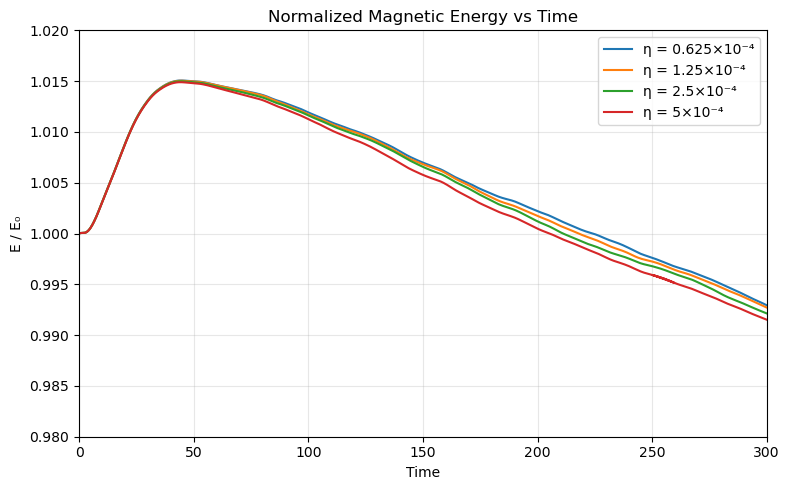

In [3]:
# --- File paths ---
File_Emag = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnMa_ApJ_.h5'
]

File_Time = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/Time_ApJ_.h5'
]

labels = [
    'η = 0.625×10⁻⁴',
    'η = 1.25×10⁻⁴',
    'η = 2.5×10⁻⁴',
    'η = 5×10⁻⁴'
]

# Helper function to load DS1 from a file
def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]        # get first dataset name, e.g. 'DS1'
        return f[key][:]

# --- Load all runs ---
energies = []
times = []
for efile, tfile in zip(File_Emag, File_Time):
    energies.append(load_dataset(efile))
    times.append(load_dataset(tfile))

# --- Normalize energies ---
normalized = [E / E[0] for E in energies]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.xlim(0, 300) 
plt.ylim(0.98, 1.02)

for t, Enorm, label in zip(times, normalized, labels):
    plt.plot(t, Enorm, label=label)

plt.xlabel("Time")
plt.ylabel("E / E₀")
plt.title("Normalized Magnetic Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("MagneticEnergyPlot.png", dpi=300)
plt.show()